In [2]:
from matplotlib import pyplot as plt

plt.rcParams['axes.labelsize'] = 14  # размер подписей осей

import pandas as pd
import numpy as np

from scipy.optimize import curve_fit
from scipy.stats import chi2_contingency

# Диффракция Френеля на щели


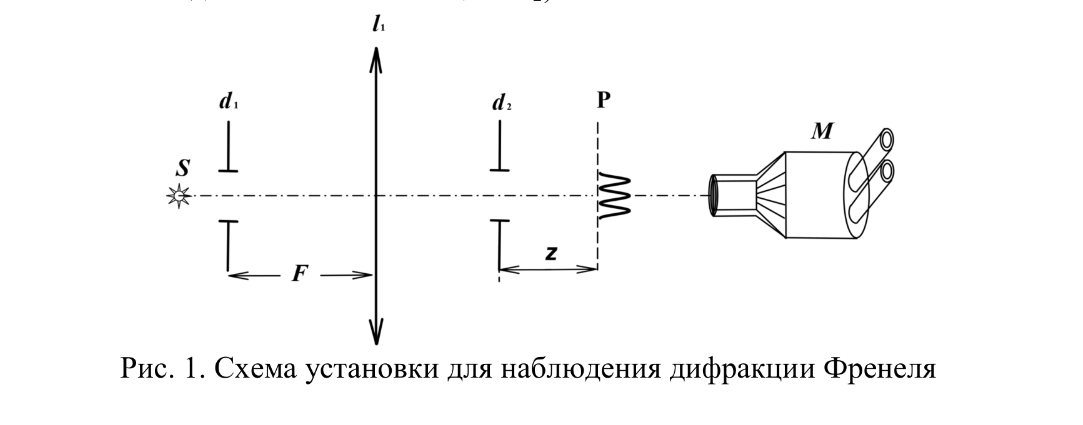

 - $d_1$ позволяет нам регулировать пространственную когерентность источника
    - вместе с регулировкой интенсивности источника позволяет нам добиться наиболее четких темных полос
 - $l_1$ собирает плоский фронт 
    - в его плоскоте мы убеждаемся используя зрительную трубу, настроенную на бесконечность. Смотря в нее и наблюдая засветку от источника убеждаемся, что падающий на $d_2$ фронт близок к параллельному
 - $d_2$ --- щель, на которой мы диффрагируем


## Определение ширины щели по изображению в зоне геометрической оптики

- с помощью калибровочной шкалы ранее мы получили масштаб пиксель : мм по которым теперь можем измерять размеры по картинке

- мы устанавливаем микроскоп для наблюдения в зону геометрической оптики
- получаем на экране геометрическую тень щели $0.18$ мм и $0.25$ мм   
- измерения по микрометрическому винту у нас в этот момент не состоялись


 Далее мы ползаем с помощью микрометрического винта в зоне диффракции Френеля 


In [3]:
frensel_slot_data = pd.read_csv('frensel_slot.csv')

display(frensel_slot_data)

n = np.array(frensel_slot_data['n'])
z1 = np.array(frensel_slot_data['z1'])
z2 = np.array(frensel_slot_data['z2'])
m = n + 1

,n,z1,z2
0,1,22.63,23.36
1,2,18.95,16.14
2,3,16.95,13.55
3,4,16.02,11.55
4,5,15.51,10.55
5,6,15.05,9.21


In [4]:
print(z1)

[22.63 18.95 16.95 16.02 15.51 15.05]


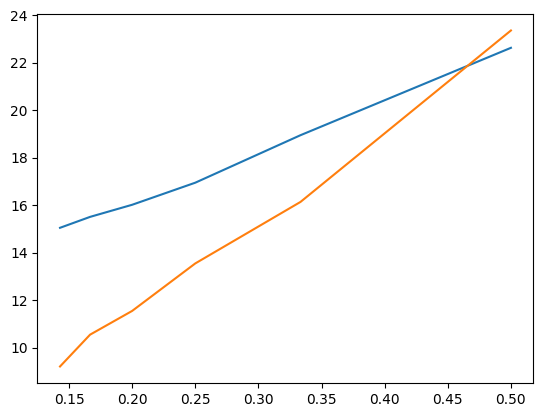

In [5]:
plt.plot(1/m, z1)
plt.plot(1/m, z2)

In [6]:
def f (x, A, b):
    return A * x + b

def calc_sigma (z : np.ndarray):
    sigma = np.zeros(len(z))
    sigma[0] = np.abs(z[1] - z[0])

    for i in range (1, len(z) - 1):
        sigma[i] = (np.abs(z[i] - z[i + 1]) + np.abs(z[i-1] - z[i])) / 2

    sigma[-1] = np.abs(z[-1] - z[-2])
    return sigma / 7

popt_z1, pcov_z1 = curve_fit(f,1/m, z1, sigma = calc_sigma(z1), absolute_sigma = True)
popt_z2, pcov_z2 = curve_fit(f,1/m, z2, sigma = calc_sigma(z2), absolute_sigma = True)

Azm1,bzm1 = popt_z1
Azm1_err, bzm1_err = np.sqrt(np.diag(pcov_z1))


chi2_z1 = np.sum(((z1 - f(1/m, Azm1, bzm1)) / calc_sigma(z1))** 2)
print(calc_sigma(z1))
print(f'z1 stats: \n popt : {popt_z1} \n pconv : {pcov_z1}, A +- A_err : {Azm1} +- {Azm1_err} \n b +- b_err : {bzm1} +- {bzm1_err}\n chi2_z1 : {chi2_z1}')


Azm2,bzm2 = popt_z2
Azm2_err, bzm2_err = np.sqrt(np.diag(pcov_z2))
chi2_z2 = np.sum(((z2 - f(1/m, Azm2, bzm2)) / calc_sigma(z2))** 2)
print(f'z2 stats: \n popt : {popt_z2} \n pconv : {pcov_z2}, A +- A_err : {Azm2} +- {Azm2_err} \n b +- b_err : {bzm2} +- {bzm1_err}\n chi2_z1 : {chi2_z1}')



[0.52571429 0.40571429 0.20928571 0.10285714 0.06928571 0.06571429]
z1 stats: 
 popt : [19.67077874 12.20795891] 
 pconv : [[ 1.04147459 -0.1768093 ]
 [-0.1768093   0.0317805 ]], A +- A_err : 19.670778737072684 +- 1.0205266226818963 
 b +- b_err : 12.207958912413481 +- 0.17827086075613122
 chi2_z1 : 3.9192674699522523
z2 stats: 
 popt : [38.29669752  3.95041416] 
 pconv : [[ 4.13228536 -0.75270208]
 [-0.75270208  0.14740007]], A +- A_err : 38.29669752310259 +- 2.032802341429661 
 b +- b_err : 3.9504141554192445 +- 0.17827086075613122
 chi2_z1 : 3.9192674699522523



## Линеаризация зависимости расстояния до щели $z$ (видимо, от фокуса микроскопа) от числа открытых зон Френеоля (= число темных полос + 1 в нашем маленьком частном убожестве)  

поскольку мы не произвели корректных измерений диапазона в котором наблюдается "норм четкость" картинка, то ошибки измерения $z$ здесь --- выдумка-подгон под значение $p$ (для того, чтобы срослось, нужно предположить, что мы видим четку картинку в +- 10 % от $z$ соответствующего полностью открытой зоне Френеля)

- при $m = 1$ мы видим светлую полосу в центре
- при $m = 2$ возникает темная полоса $n = 1$
- при $m = 3$ снова светлое в центре и появляется дополнительное темная $n = 2$


в диапазоне $m \propto 1$ справделива зависимость $m = n + 1$

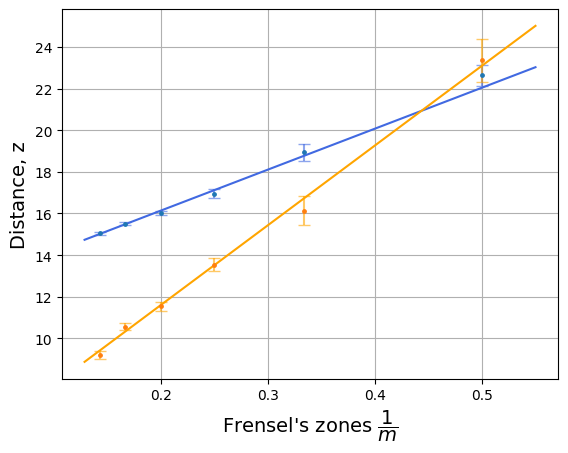

In [7]:

revm_plt_array = np.linspace(np.min(1/m) * 0.9, np.max(1/m) * 1.1)


plt.plot(revm_plt_array, f(revm_plt_array, Azm1, bzm1), color = 'royalblue')
plt.errorbar(1/m, z1, yerr = calc_sigma(z1), linestyle = '', color = 'royalblue', alpha = 0.6, capsize = 4)
plt.scatter(1/m,z1,s = 6, zorder = 10)

plt.plot(revm_plt_array, f(revm_plt_array, Azm2, bzm2), color = 'orange')
plt.errorbar(1/m, z2, yerr = calc_sigma(z2), linestyle = '',color = 'orange', alpha = 0.6, capsize = 4)
plt.scatter(1/m, z2, s = 6, zorder = 10)

plt.grid()

plt.xlabel(r"Frensel's zones $\dfrac{1}{m}$")
plt.ylabel(r"Distance, z")

plt.show()

In [8]:
lam = 515 * 1e-6# mm
dlam = 36 * 1e-6# mm

def dfromA (lam, dlam, A, dA):
    

    d = np.sqrt(4 * A * lam)
    d_err = np.sqrt(np.sqrt(4 * lam)/(2 * np.sqrt(A)) * dA ** 2 + np.sqrt(4 * A)/(2 * np.sqrt(lam)) * dlam ** 2)

    return d, d_err 


dzm1, dzm1_err = dfromA(lam,dlam, Azm1, Azm1_err)
dzm2, dzm2_err = dfromA(lam,dlam, Azm2, Azm2_err)

print (f"dzm1 : {dzm1} + {dzm1_err} mm") # by image 0.18
print (f"dzm2 : {dzm2} + {dzm2_err} mm") # by image 0.25


dzm1 : 0.20130028365198527 + 0.07300138142710366 mm
dzm2 : 0.2808757677294204 + 0.12310103167831135 mm


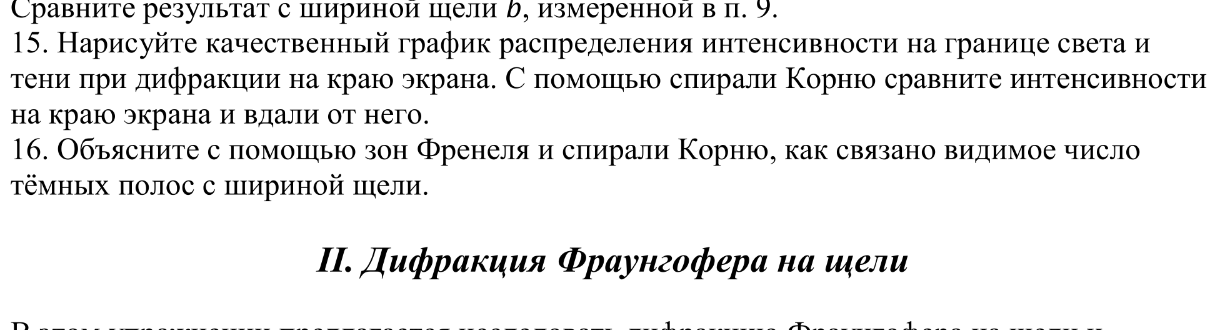

Если не сделаю чего-то более качественно (наверное впдалу, но мб посмотрю), то просто вставить спираль Карню отрисованную поэтапно и сказать слова, которые предлагаются у Паучкова

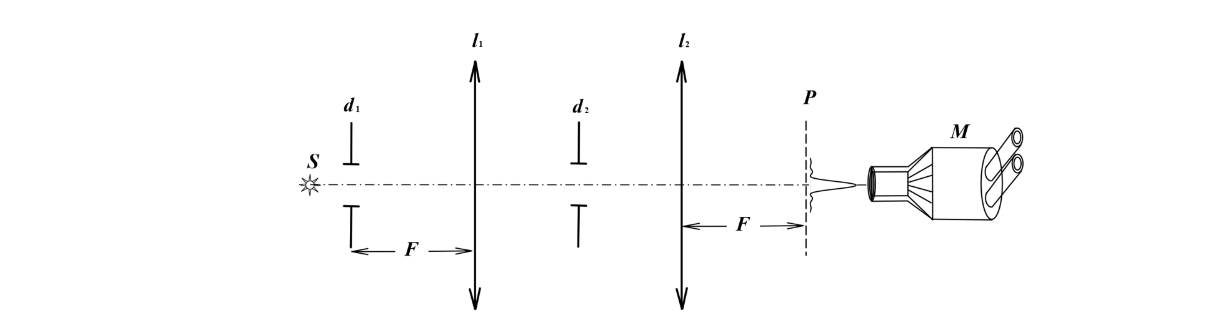

# Диффракция Фраунгофера на Щели

- все то же самое, только теперь $l_2$ делает нам пространственное преобразование Фурье и мы от углового распределения интенсивностей переходим к координатам в фокусе микроскопа (уточнитьь формулировку, но $\pm$ это)

- Обрабатываем изображение и вынимаем зависимость $\xi(m)$ координаты темной полосы от ее номера. Из углового коэффицеинта этой зависимости достаем $d_2$

- попиксельное определение дает $b_1 = 0.478$ и $b_2 = 0.710$

- по винту, ну ... пересчитай как-нибудь

In [50]:
fraun_slot_data = pd.read_csv('fraun_slot.csv')

display(fraun_slot_data)

m = np.array(fraun_slot_data['n'], dtype = float)
px1 = np.array(fraun_slot_data['px1'],dtype = float)
px2 = np.array(fraun_slot_data['px2'],dtype = float)


,n,px1,px2
0,-5,380,801
1,-4,534,899
2,-3,730,1011
3,-2,895,1138
4,-1,1075,1244
5,1,1428,1489
6,2,1615,1590
7,3,1776,1702
8,4,1962,1815
9,5,2133,1932


A1 : 0.1926161175070676 +- 6.347156563049665e-07 mm  
 B2 : -0.0034934497816593926 +- 6.981869069407218e-06 mm
A2 : 0.12446407304485918 +- 5.754449930381069e-07 mm  
 B2 : 0.0033842794759827433 +- 6.329895739170888e-06 mm


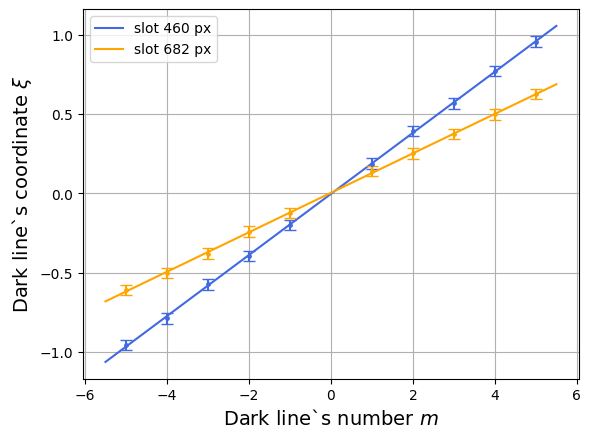

In [58]:

xi1 = (px1 - 1256) / 916 # convert to mms 
xi1_err = 30 / 916 # I believe (in px / (px / mm))
xi2 = (px2 - 1359) / 916 # convert to mms 
xi2_err = 30 / 916 # still believe 

def f (x, A, b):
    return A * x + b
 

popt1, pcov1 = curve_fit(f, m, xi1)
popt2, pcov2 = curve_fit(f, m, xi2)

A1, b1 = popt1 
A2,b2 = popt2
A1_err, b1_err = np.sqrt(np.diag(pcov1) ** 2)
A2_err, b2_err = np.sqrt(np.diag(pcov2) ** 2)

m_plot_array = np.linspace(1.1 * min(m), 1.1 * max(m))

plt.plot(m_plot_array, f(m_plot_array, A1, b1), color = 'royalblue', label = 'slot 460 px' )
plt.errorbar(m, xi1, yerr = xi1_err, linestyle = '', capsize = 4, color = 'royalblue')
plt.scatter(m, xi1,zorder = 10, s = 6, color = 'royalblue')

plt.plot(m_plot_array, f(m_plot_array, A2, b2), color = 'orange', label = 'slot 682 px')
plt.errorbar(m, xi2, yerr = xi1_err, linestyle = '', capsize = 4, color = 'orange')
plt.scatter(m, xi2,zorder = 10, s = 6, color = 'orange')

plt.grid()

plt.legend()

plt.ylabel(r'Dark line`s coordinate $\xi$')
plt.xlabel(r'Dark line`s number $m$')


print(f'A1 : {A1} +- {A1_err} mm  \n B2 : {b1} +- {b1_err} mm')
print(f'A2 : {A2} +- {A2_err} mm  \n B2 : {b2} +- {b2_err} mm')

In [63]:
f = 170 #mm +- 10
f_err = 10 # mm 

b1 = np.mean(f * lam / A1)
berr1 = b1 * np.sqrt((f_err / f) ** 2 + (dlam / lam) ** 2)

b2 = np.mean(f * lam / A2)
berr2 = b2 * np.sqrt((f_err / f) ** 2 + (dlam / lam) ** 2)

print(f"b1 = {b1} +- {berr1}") # 0.478
print(f"b2 = {b2} +- {berr2}") # 0.709 



b1 = 0.4545310181365666 +- 0.041525892138320745
b2 = 0.70341583605773 +- 0.06426397533059822


# Диффракция Фраунгофера на двух щелях 
- берутся 2 щели, в зоне геом.оптики смотрим их ширины и расстояние между ними
- получаем диффракционную картину и по количеству темных и их ширине полос интерференции внутри диффракционного максимума вычисляем параметры щелей

$$\Delta x_{дифр} = 2f \frac{\lambda}{d} \quad \delta x_{интерфер}=f\dfrac{\lambda}{D}\quad N = \dfrac{2D}{d}$$

- тут очень большая погрешность при определении $\delta x$ при ручной обработке. Прогони через код и построй график, по нему там я не знаю $1/\sqrt{2}$ как нибудь ширину достать или чей-нибудь критерий видимости притянуть

In [70]:
N = 8

deltax = 40.4 / 961 # meaned mm

Deltax = 744 / 961 # meaned mm

d = 2 * f * lam / Deltax 
d_err = 2 * f * dlam / Deltax 
D = f * lam / deltax
D_err = f * dlam / deltax

print (f'd : {d} +- {d_err} mm')
print (f'D : {D} +- {D_err} mm')

d : 0.22617083333333332 +- 0.01581 mm
D : 2.082563118811881 +- 0.1455772277227723 mm
